In [2]:
import pandas as pd

df=pd.read_csv('../datasets/processed/DSGP1.csv')
df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,Cluster_Label,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,1,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,1,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,1,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,0,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,0,-1.080854,-0.187889,0.928905


In [3]:
from sklearn.model_selection import GridSearchCV, train_test_split,StratifiedKFold,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score
from collections import Counter


X = df.drop(["Cluster_Label"], axis=1)
Y = df["Cluster_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)


smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)
print("Class distribution after SMOTETomek:", Counter(y_train_resampled))


rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

grid_search.fit(X_train_resampled, y_train_resampled)


print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_resampled)
y_val_pred = best_model.predict(X_test)

training_accuracy = accuracy_score(y_train_resampled, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_val_pred)

print(f"Training Accuracy: {training_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {testing_accuracy * 100:.2f}%")


Class distribution after SMOTETomek: Counter({0: 385, 1: 385})
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training Accuracy: 99.48%
Validation Accuracy: 97.41%


In [4]:
X.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,-1.080854,-0.187889,0.928905


In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_val_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97        97
           1       0.98      0.97      0.97        96

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193



In [6]:
import numpy as np

193


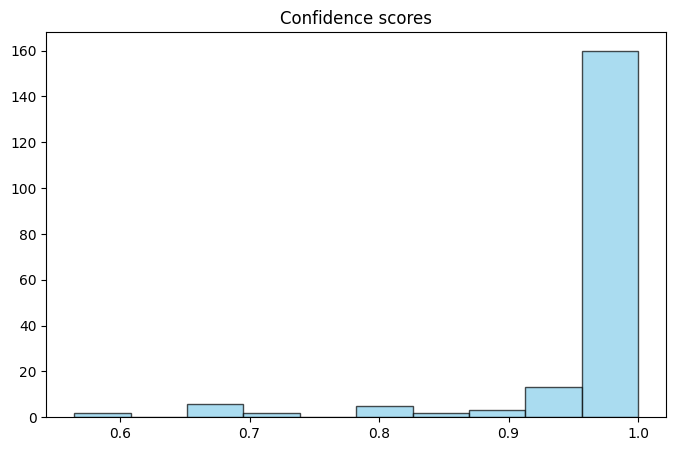

In [34]:
predicted_probablity=best_model.predict_proba(X_test)
predict_class=np.argmax(predicted_probablity)
confidence=[]
for val in predicted_probablity:
    confidence.append(np.max(val))
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Confidence scores')
print(len(confidence))

In [19]:
list_threshold=[]
for i in range(5,20,5):
    threshold=np.percentile(confidence,i)
    print(f'{i}th percentile: {threshold:.2f}')
    list_threshold.append(threshold)


5th percentile: 0.77
10th percentile: 0.91
15th percentile: 0.95


0.5647438729571082
0.708745412267471
0.6716313755688755
0.7207791375291375
0.6774877393847984
0.5676370639164757
0.6859261086136084
0.6752639182712713
0.6694564402101164
0.6883342956063545
10


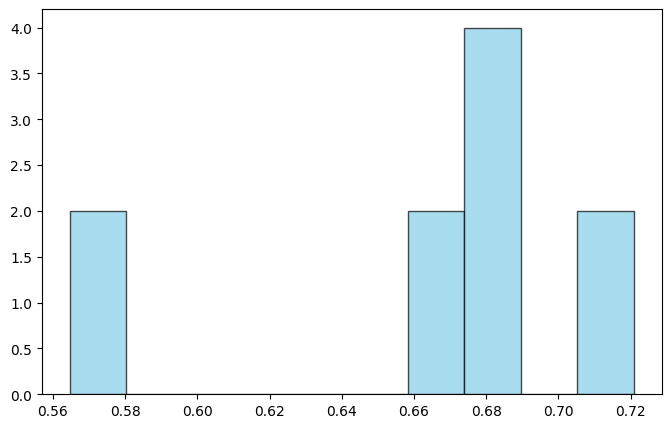

In [31]:

lowones5th=[]
for values in confidence:
    if values<0.76:
        print(values)
        lowones5th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones5th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones5th))

0.7962113997113996
0.5647438729571082
0.8188590037413568
0.708745412267471
0.8630749944499942
0.7999047847577262
0.8059978126448715
0.6716313755688755
0.7207791375291375
0.6774877393847984
0.8772114898989903
0.5676370639164757
0.8556631938323116
0.6859261086136084
0.6752639182712713
0.9030604860825449
0.6694564402101164
0.6883342956063545
0.8222884468472702
0.9046150238650238
20


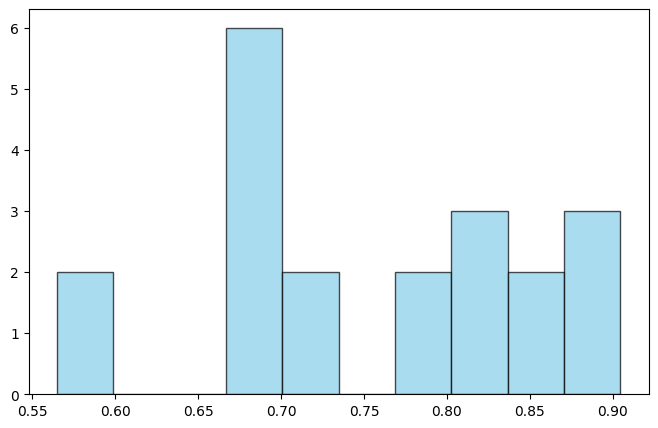

In [35]:

lowones10th=[]
for values in confidence:
    if values<0.91:
        print(values)
        lowones10th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones10th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones10th))

0.9349845779220783
0.7962113997113996
0.5647438729571082
0.8188590037413568
0.708745412267471
0.9377177307986133
0.8630749944499942
0.7999047847577262
0.8059978126448715
0.9320407864194629
0.6716313755688755
0.7207791375291375
0.6774877393847984
0.8772114898989903
0.9206034986255573
0.5676370639164757
0.8556631938323116
0.9138974220224221
0.9397718421284599
0.9461275578996166
0.6859261086136084
0.9464142593517595
0.6752639182712713
0.9030604860825449
0.949392721249339
0.9157680791430791
0.6694564402101164
0.6883342956063545
0.8222884468472702
0.9046150238650238
30


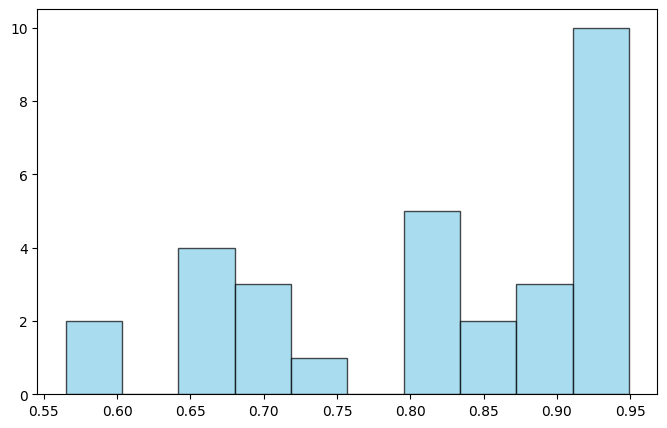

In [29]:

lowones15th=[]
for values in confidence:
    if values<0.95:
        print(values)
        lowones15th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones15th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones15th))

In [36]:
20/193

0.10362694300518134

In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.98444928 0.97926069 0.98445596 0.99481865 0.97409048]
Mean F1-Score: 0.983415012847004


In [13]:
from sklearn.preprocessing import StandardScaler



X=df.drop(['Cluster_Label'],axis=1)

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [14]:
df1 = pd.concat([df['Cluster_Label'], Scaled_df], axis=1)
df1.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,1,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,1,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,0,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [15]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred = dt_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9585492227979274
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        97
           1       0.99      0.93      0.96        96

    accuracy                           0.96       193
   macro avg       0.96      0.96      0.96       193
weighted avg       0.96      0.96      0.96       193



In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input
from sklearn.model_selection import train_test_split

X=df1.drop('Cluster_Label',axis=1)
Y=df1['Cluster_Label']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)


model = Sequential([
    Input(shape=(7,)),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_resampled, y_resampled, validation_data=(X_test, y_test), epochs=30, batch_size=64)

ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_pred=model.predict(X_test)
 
y_pred_labels = (y_pred > 0.5).astype(int)  
print(classification_report(y_test, y_pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        81
           1       0.99      1.00      1.00       112

    accuracy                           0.99       193
   macro avg       1.00      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193



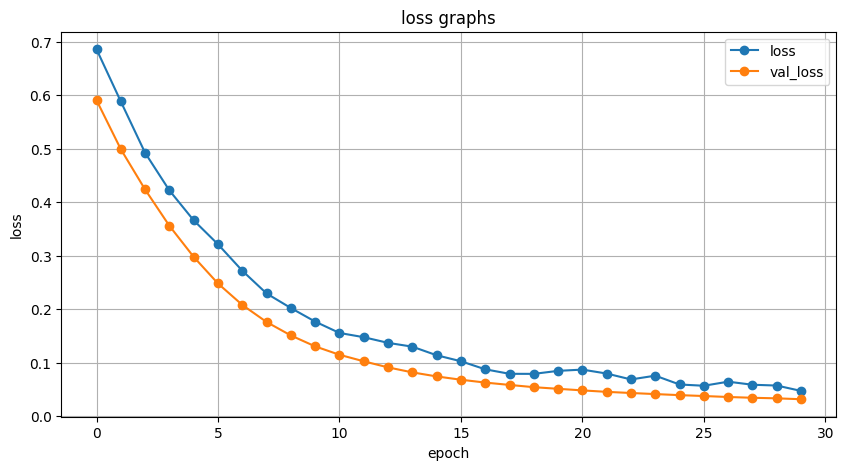

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss',marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("loss graphs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle
with open('irrigation_optimization_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)